In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
warnings.filterwarnings('ignore')
import os
from pathlib import Path
from scipy.optimize import curve_fit
plotsdir = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_Tlife_conditions/Plots/'
#dataout  = '/nfs/scistore15/saricgrp/bmeadowc/Scratch/Collagen/model_strict_tetramer/EquilibriumSeededWorkflow/Plotting/'

import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

Current recursion limit: 3000


In [2]:
clrs00 = ['#A10035','#2A0944','lightsalmon','#3FA796','#FEC260','pink','#A10035','#2A0944','#3FA796']
cmap0 = plt.cm.get_cmap('Spectral_r') #YlOrBr
cmap1 = plt.cm.get_cmap('YlOrBr') #YlOrBr
#cmap2 = plt.cm.get_cmap('twilight') #twilight
cmap2 = plt.cm.get_cmap('GnBu') #twilight
cmap3 = plt.cm.get_cmap('BuPu') #twilight
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','#f5f5f5']
clrs2 = ['#ffffcc','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84','lightsalmon']
clrs3 = ['#c7e9b4','#7fcdbb','#1d91c0','#225ea8','#0c2c84']
clrs = ['#a6611a','#dfc27d','olive','#80cdc1','#018571','steelblue','slateblue','#0c2c84','lightsalmon']
ClrsRiciChosenHalf = ["#7883acff","#73457aff","#b25268ff","#d49995ff"]


In [5]:
### ---------- Original Data --------- ###
MPs = [0.06, 0.12, 0.27, 0.39, 0.6, 0.81, 1.0]
TLifeDenseControl = [1099864214.852721, 647244015.958075, 302691299.9283709, 193380543.86555687, 125399124.23642237, 72382977.98185535, 54627694.158685945]
TLifeDenseControlSTD = [44699278.24732293,  22813613.258780956,  16283695.86598525, 10284609.004496682, 5920680.203341648, 7337765.993784864, 1091191.1142829212]
Taus_Av=[16401.45832306 , 10454.5752332   ,4405.37357503 , 3018.91964483,  2236.18922721 , 1977.03609215 , 1452.91837506]

Taus_Std=[604.8449615   , 49.68744122 , 935.75454548 , 288.93094047 , 414.79754408 , 340.46029844,  677.22418629]
#[0.06,0.12,0.27,0.39,0.6,0.81,1.0]
#TLifeDenseControl = [1097480059.8217652, 633698216.2815531, 302139446.80269545, 193633556.59936503, 125156485.30485937, 72212995.20807625, 54841481.20182556]

MPs = [0.27,0.6,0.81] #0.01,0.03, 0.06, 0.09, 0.18, 0.27, 0.6, 0.81,1.0
MPs = [0.06,0.27,0.6,0.81]

Taus_Av_PE=[16401.45832306, 4405.37357503 , 3018.91964483,  2236.18922721] # , 1452.91837506]
Taus_Std_PE=[604.8449615,935.75454548 ,  414.79754408 , 340.46029844] #,  677.22418629]
#[0.27,0.6,0.81]
#977642565.3211662, 640370975.9281248, 651562886.114887, 
TlifePostRel = np.multiply([1121276089.2516322, 242575151.46067607, 111241652.70475224, 77871367.60432142],1)
TlifePostRelSTD = np.multiply([237722883.63031173, 79677118.51953454, 12663803.470451646, 11336521.069283152],1)

MPs = [0.01,0.09,0.81]
TlifeKapp1 = [2571966688.519832, 266875183.57272395, 30764007.07397084]
TlifeKapp1STD = [209243382.988155, 19874396.783768047, 342229.3801866104]

TrelKapp1=[65495.07377449, 12644.76172067,  1977.03609215]
TrelKapp1STD=[2323.14021505,  260.39873011,  340.46029844]

MPs = [0.06, 0.12 ,0.81]
TrelKapp1=[24708.04151849 ,15685.80292832 , 3640.04997777] #[ 25179.59632991 ,15928.52353846 , 2975.81510645] #56017.33731213,[56017.33731213, 25179.59632991 ,15928.52353846 , 3250.73893644]
TrelKapp1STD=[532.51426695, 1157.21153907  ,169.14760174] #1966.72649592 , [1966.72649592  ,532.51426695, 1157.21153907 , 317.39570366]
#TlifeKapp1STD =[ 462.49794556, 1645.64502772 , 352.85327497  ,143.16342003]
TlifeKapp1 = [1334926762.2360215, 664285409.2461318, 83305805.7478559] #3115360685.729898,
TlifeKapp1STD = [30052581.40911424, 23251135.385540187, 5599878.221882703] #327203574.52201337, 
#[48855.96980052 24708.04151849 15685.80292832  3640.04997777]
#[4297.60750816 2468.03418211  462.37619043  485.67088259]
MPs = [0.01,0.03,0.06,0.09,0.81]

TrelKrod200 = [95436.19055357, 33486.8217798 , 17417.42407943, 10772.19023943 , 1330.97379749]
TrelKrod200STD = [1811.51949271, 1501.09646689, 1590.52492499,  377.24480252,    0.]

MPs = [0.06,0.09,0.81] #[0.06,0.09,0.81]
TrelKrod200 = [17417.42407943, 10772.19023943 , 1330.97379749]
TrelKrod200STD = [1590.52492499,  377.24480252,    0.]
TlifeKrod200 = [1321468775.520191, 792412300.483315, 73527406.75765958] #[1099864214.852721, 793135482.3090843, 73504696.14467555]
TlifeKrod200STD = [295304252.65035456, 48616720.61634694, 4318059.3168117115] #[ 0, 48419668.72605008, 4399304.006076905]


MPs = [0.01,0.03,0.06,0.09,0.12,0.18,0.27,0.81]
TrelKrod200 =[95494.1243732,  32639.85169152 ,15941.67173743, 10765.35027132, 9171.95366741 , 6843.72890829,  4511.68239375 , 1589.54200391]
TrelKrod200STD =[1841.03577615 ,1292.72707835,1610.01117314,  371.07938745 , 230.78384314,    0.    ,      599.70267581,  211.19491711]
TlifeKrod200 = [3489325282.670342, 1664403617.9263566, 978197095.0190643, 792412300.483315, 471944815.9709208, 330669057.67833817, 226365474.44047508, 73527406.75765958]
TlifeKrod200STD = [326584516.8923372, 25144362.090471983, 126402164.63291268, 48616720.61634694, 51948631.85829505, 0.0, 6892635.399522559, 4318059.3168117115]

MPs = [0.06,0.09,0.12,0.18,0.27,0.81]
TrelKrod200 =[15941.67173743, 10765.35027132, 9171.95366741 , 6843.72890829,  4511.68239375 , 1589.54200391]
TrelKrod200STD =[1610.01117314,  371.07938745 , 230.78384314,    0.    ,      599.70267581,  211.19491711]
TlifeKrod200 =[978197095.0190643, 792412300.483315, 653733098.0544608, 409161729.74787307, 232609945.51870322, 73527406.75765958]
TlifeKrod200STD = [126402164.63291268, 48616720.61634694, 35000554.80507952, 0.0, 24072284.824616868, 4318059.3168117115]

MPs = [0.06,0.18,0.27,0.81]
TrelKrod200 =[15941.67173743,  6843.72890829,  4511.68239375 , 1589.54200391]
TrelKrod200STD =[1610.01117314,     0.    ,      599.70267581,  211.19491711]
TlifeKrod200 =[978197095.0190643, 409161729.74787307, 232609945.51870322, 73527406.75765958]
TlifeKrod200STD = [126402164.63291268,  0.0, 24072284.824616868, 4318059.3168117115]
#TlifeKrod200 = [978197095.0190643, 792412300.483315, 471944815.9709208, 330669057.67833817, 226365474.44047508, 73527406.75765958]
#TlifeKrod200STD = [126402164.63291268, 48616720.61634694, 51948631.85829505, 0.0, 6892635.399522559, 4318059.3168117115]



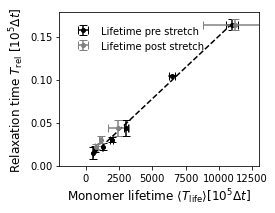

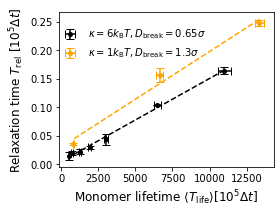

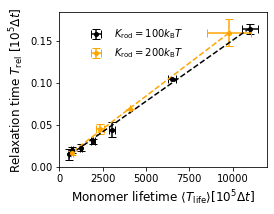

In [13]:
figPR,axPR = plt.subplots(1,figsize = (4,3))
x0,y0 = np.array(np.divide(TLifeDenseControl,10**5)),np.array(np.divide(Taus_Av,10**5))
m0,b0 = np.polyfit(x0,y0,1)
x00 = x0.reshape(-1,1)
a0,_,_,_ = np.linalg.lstsq(x00, y0)
axPR.errorbar(np.divide(TLifeDenseControl,10**5),np.divide(Taus_Av,10**5),yerr = np.divide(Taus_Std,10**5), xerr = np.divide(TLifeDenseControlSTD,10**5), color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = "Lifetime pre stretch")
axPR.plot(x0,np.divide(m0*x0+b0,1),color = 'black',linestyle = '--') #,label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')
axPR.errorbar(np.divide(TlifePostRel,10**5),np.divide(Taus_Av_PE,10**5),yerr = np.divide(Taus_Std_PE,10**5), xerr = np.divide(TlifePostRelSTD,10**5), color = 'grey',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = "Lifetime post stretch")
axPR.set_xlabel(r'Monomer lifetime $\langle T_{\mathrm{life}}\rangle [10^5\Delta t]$',fontsize = 12)
axPR.set_ylabel(r"Relaxation time $T_{\mathrm{rel}}$ [$10^5\Delta t$]",fontsize = 12)

text = r'$T_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$'
text = r'$T_{\mathrm{rel}} \propto \langle T_{\mathrm{life}}\rangle$'
#axPR.text(15,0.6,text,color = 'black',fontsize = 12)
#---- log-log axis---#
#axPR.set_xscale('log')
#axPR.set_yscale('log')
axPR.set_xlim([-2000,13000])
figPR.legend(frameon = False,loc =[0.25,0.74],fontsize = 10)
figPR.tight_layout()
figPR.savefig(plotsdir + 'MasterTlifeTrelax_PostRelaxation.png',dpi = 300)

#ax.set_xticks([0,200,400,600],['0','200','400','600'])
#ax.set_yticks([0,0.2,0.4,0.6,0.8],['0','0.2','0.4','0.6','0.8'])

# figPR.tight_layout()
# figPR.savefig(plotsdir + 'MasterTlifeTrelax_PostRelaxation.png',dpi = 300)

figKapp,axKapp = plt.subplots(1,figsize = (4.,3))
axKapp.errorbar(np.divide(TLifeDenseControl,10**5),np.divide(Taus_Av,10**5),yerr = np.divide(Taus_Std,10**5), xerr = np.divide(TLifeDenseControlSTD,10**5), color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = r'$\kappa = 6k_{\mathrm{B}}T, D_{\mathrm{break}} = 0.65\sigma$')
axKapp.errorbar(np.divide(TlifeKapp1,10**5),np.divide(TrelKapp1,10**5),yerr = np.divide(TrelKapp1STD,10**5), xerr = np.divide(TlifeKapp1STD,10**5), color = 'orange',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = r'$\kappa = 1k_{\mathrm{B}}T, D_{\mathrm{break}} = 1.3\sigma$')
axKapp.plot(x0,np.divide(m0*x0+b0,1),color = 'black',linestyle = '--') #,label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')
x1,y1 = np.array(np.divide(TlifeKapp1,10**5)),np.array(np.divide(TrelKapp1,10**5))
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
axKapp.plot(x1,np.divide(m1*x1+b1,1),color = 'orange',linestyle = '--')

axKapp.set_xlabel(r'Monomer lifetime $\langle T_{\mathrm{life}}\rangle [10^5\Delta t]$',fontsize = 12)
axKapp.set_ylabel(r"Relaxation time $T_{\mathrm{rel}}$ [$10^5\Delta t$]",fontsize = 12)

figKapp.legend(frameon=False,loc = [0.2,0.7])
figKapp.tight_layout()
figKapp.savefig(plotsdir + 'NewMasterTlife_Kappa1.png',dpi = 600)

figKrod,axKrod = plt.subplots(1,figsize = (4.,3))
axKrod.errorbar(np.divide(TLifeDenseControl,10**5),np.divide(Taus_Av,10**5),yerr = np.divide(Taus_Std,10**5), xerr = np.divide(TLifeDenseControlSTD,10**5), color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = r'$K_{\mathrm{rod}} = 100k_{\mathrm{B}}T$')
axKrod.errorbar(np.divide(TlifeKrod200,10**5),np.divide(TrelKrod200,10**5),yerr = np.divide(TrelKrod200STD,10**5), xerr = np.divide(TlifeKrod200STD,10**5), color = 'orange',linestyle = '',marker = 'o',markersize = 4,capsize = 4, label = r'$K_{\mathrm{rod}} = 200k_{\mathrm{B}}T$')
axKrod.plot(x0,np.divide(m0*x0+b0,1),color = 'black',linestyle = '--') #,label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')

x1,y1 = np.array(np.divide(TlifeKrod200,10**5)),np.array(np.divide(TrelKrod200,10**5))
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
axKrod.plot(x1,np.divide(m1*x1+b1,1),color = 'orange',linestyle = '--') #,label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')
#axKrod.set_xticks([0,5000,10000,15000],['0','5000','10000','15000'])
axKrod.set_xlabel(r'Monomer lifetime $\langle T_{\mathrm{life}}\rangle [10^5\Delta t]$',fontsize = 12)
axKrod.set_ylabel(r"Relaxation time $T_{\mathrm{rel}}$ [$10^5\Delta t$]",fontsize = 12)
figKrod.legend(frameon=False,loc = [0.3,0.7])
figKrod.tight_layout()
figKrod.savefig(plotsdir + 'NewMasterTlife_Krod200.png',dpi = 600)


In [ ]:
figKrod,axKrod = plt.subplots(1,figsize = (4.,3))
axKrod.errorbar(np.divide(TLifeDenseControl,10**5),np.divide(Taus_Av,10**5),yerr = np.divide(Taus_Std,10**5), xerr = np.divide(TLifeDenseControlSTD,10**5), color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = r'$K_{\mathrm{rod}} = 100k_{\mathrm{B}}T$')
axKrod.errorbar(np.divide(TlifeKrod200,10**5),np.divide(TrelKrod200,10**5),yerr = np.divide(TrelKrod200STD,10**5), xerr = np.divide(TlifeKrod200STD,10**5), color = 'orange',linestyle = '',marker = 'o',markersize = 4,capsize = 4, label = r'$K_{\mathrm{rod}} = 200k_{\mathrm{B}}T$')
axKrod.plot(x0,np.divide(m0*x0+b0,1),color = 'black',linestyle = '--') #,label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')

x1,y1 = np.array(np.divide(TlifeKrod200,10**5)),np.array(np.divide(TrelKrod200,10**5))
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
axKrod.plot(x1,np.divide(m1*x1+b1,1),color = 'orange',linestyle = '--') #,label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')
#axKrod.set_xticks([0,5000,10000,15000],['0','5000','10000','15000'])
axKrod.set_xlabel(r'Monomer lifetime $\langle T_{\mathrm{life}}\rangle [10^5\Delta t]$',fontsize = 12)
axKrod.set_ylabel(r"Relaxation time $T_{\mathrm{rel}}$ [$10^5\Delta t$]",fontsize = 12)
figKrod.legend(frameon=False,loc = [0.3,0.7])
figKrod.tight_layout()
figKrod.savefig(plotsdir + 'NewMasterTlife_Params.png',dpi = 600)

1.4558827094294902e-05
3.467758505373821e-05


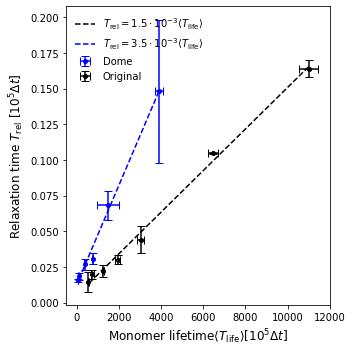

In [ ]:

MPsV = [0.03,0.06,0.09,0.18,0.27]
TlifeDomeSTD = np.divide([191184179.20658043, 516847632.13053596, 33002953.407984972, 23590243.39952457, 5839307.490375702, 1409831.3360827242],10) #, 1449709.8551425608]
TlifeDome = np.divide([3895387776.415806, 1490984039.0871267, 749758994.7527883, 385176820.20860887, 81341300.00684947, 41799583.3318159],10) #, 18689795.66494985]
Tau_Dome = np.divide([148116.1925427, 68235.87589888, 30723.74236422, 26808.96695292, 18514.41350257, 15686.35297297],10)
Tau_Dome_STD = np.divide([49943.53425274, 10017.08163037, 3746.40370583, 3698.28181342, 2568.4389538, 988.80495353],10)
fig,ax = plt.subplots(1,figsize = (5.,5))

ax.errorbar(np.divide(TlifeDome,10**5),np.divide(Tau_Dome,10**5),xerr = np.divide(TlifeDomeSTD,10**5), yerr = np.divide(Tau_Dome_STD,10**5), color = 'blue',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = "Dome")
ax.errorbar(np.divide(TLifeDenseControl,10**5),np.divide(Taus_Av,10**5),yerr = np.divide(Taus_Std,10**5), xerr = np.divide(TLifeDenseControlSTD,10**5), color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = "Original")
x1,y1 = np.array(np.divide(TLifeDenseControl,10**5)),np.array(np.divide(Taus_Av,10**5))
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
print(m1)
ax.plot(x1,np.divide(m1*x1+b1,1),color = 'black',linestyle = '--',label = r'$T_{\mathrm{rel}} = 1.5\cdot 10^{-3}\langle T_{\mathrm{life}}\rangle$')
#ax.set_xlim(0.0,4000)
x1,y1 = np.array(np.divide(TlifeDome,10**5)),np.array(np.divide(Tau_Dome,10**5))
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
print(m1)
ax.plot(x1,np.divide(m1*x1+b1,1),color = 'blue',linestyle = '--',label = r'$T_{\mathrm{rel}} = 3.5\cdot 10^{-3}\langle T_{\mathrm{life}}\rangle$')
ax.set_xlabel(r'Monomer lifetime$\langle T_{\mathrm{life}}\rangle [10^5\Delta t]$',fontsize = 12)
ax.set_ylabel(r"Relaxation time $T_{\mathrm{rel}}$ [$10^5\Delta t$]",fontsize = 12)
#ax.set_yscale('log')
#ax.set_xscale('log')
#ax.set_ylim(0,0.2)
ax.legend(frameon = False,loc = 'upper left')
fig.tight_layout()
fig.savefig(plotsdir + 'MasterTlife_Trel_DOME.png',dpi = 1000)




In [ ]:
# figConc,axConc = plt.subplots(1,figsize = (4.,2.7))


# axConc.errorbar(np.divide(TLifeDenseControl,10**5),np.divide(Taus_Av,10**5),yerr = np.divide(Taus_Std,10**5), xerr = np.divide(TLifeDenseControlSTD,10**5), color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = "Original")
# axConc.errorbar(np.divide(TLife_3QuartersDensity,10**5),np.divide(Taus_3QuartersDensity,10**5),yerr = np.divide(Taus_3QuartersDensitySTD,10**5), xerr = np.divide(TLife_3QuartersDensitySTD,10**5), color = 'green',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = "Three quarters density")
# axConc.errorbar(np.divide(TLife_HalfDensity,10**5),np.divide(Taus_HalfDensity,10**5),yerr = np.divide(Taus_HalfDensitySTD,10**5), xerr = np.divide(TLife_HalfDensitySTD,10**5), color = 'orange',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = "Half density")
# axConc.plot(x1,np.divide(m1*x1+b1,1),color = 'black',linestyle = '--',label = r'$\tau_{rel} = 5\times 10^{-4}\langle T_{\mathrm{life}}\rangle$')
# x1,y1 = np.array(np.divide(TLife_3QuartersDensity,10**5)),np.array(np.divide(Taus_3QuartersDensity,10**5))
# m1,b1 = np.polyfit(x1,y1,1)
# x11 = x1.reshape(-1,1)
# a1,_,_,_ = np.linalg.lstsq(x11, y1)
# axConc.plot(x1,np.divide(m1*x1+b1,1),color = 'green',linestyle = '--',label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')

# axConc.set_xlabel(r'Monomer lifetime$\langle T_{\mathrm{life}}\rangle [10^5\Delta t]$',fontsize = 12)
# axConc.set_ylabel(r"Relaxation time $T_{\mathrm{rel}}$ [$10^5\Delta t$]",fontsize = 12)
# axConc.set_yscale('log')
# axConc.set_xscale('log')
# axConc.legend(frameon = False)

# print(TLife_HalfDensity)
# print(Taus_HalfDensity)
# 1.26e4
# 6.29e3
# Taus_Other_HalfDensity = [6.29e3,1.26e4]
# MPs = [0.09,0.18]
# MPs_Norm = [0.03,0.06,0.09,0.18,0.27,0.6]
# fig,ax = plt.subplots(1,figsize = (4.,2.7))
# ax.plot(MPs_Norm,Taus_HalfDensity)
# ax.plot(MPs,Taus_Other_HalfDensity)